# Missed Refund Exploratory Analysis

## Business Context

This notebook performs exploratory data analysis on the combined synthetic monthly refund datasets generated in previous notebooks.

The objective is to identify operational trends, understand the characteristics of missed refund cases and generate evidence-based recommendations to improve the refund process.

---

## Objectives

This notebook explores:

- Monthly operational workload
- Refund type distributions
- Root causes of missed refunds
- Department performance
- Outstanding refund values
- Financial exposure
- Opportunities for operational improvement

In [1]:
# Import libraries

import pandas as pd
from pathlib import Path

## Load Monthly Snapshot Data

Load all monthly CSV files from the raw data folder and combine them into one DataFrame.

In [2]:
# Locate all monthly snapshot files

data_folder = Path("../data/raw")

snapshot_files = sorted(
    data_folder.glob("powerbi_snapshot_*.csv")
)

print(f"Files found: {len(snapshot_files)}")

Files found: 18


In [3]:
# Load and combine all monthly snapshot files

monthly_dataframes = []

for file in snapshot_files:
    monthly_df = pd.read_csv(file)
    monthly_dataframes.append(monthly_df)

debt_held_df = pd.concat(
    monthly_dataframes,
    ignore_index=True,
)

debt_held_df.head()

,Case ID,Policy Number,Client Number,Snapshot Date,Outstanding Amount,Cancellation Status,Cancelling Department,Cancelling Agent,Agent Working,Refund Type,Root Cause,Customer Contacted,Outcome
0,DH000001,PET000001,CL000029,2025-01-31,3.11,Cancelled,Customer Service,CS018,DH001,Cancellation Before Premium Due,Payment Date Misunderstood,Yes,Actioned
1,DH000002,PET000002,CL000155,2025-01-31,2.39,Cancelled,Customer Service,CS008,DH002,Cancellation Before Premium Due,Waiting for Information,Yes,No Action
2,DH000003,PET000003,CL000179,2025-01-31,21.12,Cancelled,Retentions,RET013,DH001,Death of Pet,Payment Date Misunderstood,Yes,Actioned
3,DH000004,PET000004,CL000032,2025-01-31,175.71,Cancelled,Claims,CLM010,DH002,Cancellation Before Premium Due,Waiting for Information,Yes,Actioned
4,DH000005,PET000005,CL000075,2025-01-31,271.06,Cancelled,Retentions,RET015,DH002,Death of Pet,Agent Forgot,No,Actioned


In [4]:
debt_held_df.shape

(2871, 13)

## Data Quality Checks

Before analysing the data, validate that the combined dataset has:

- Correct data types
- No unexpected missing values
- No duplicate Case IDs
- Consistent categorical values

This helps ensure that any insights generated from the analysis are based on reliable data.

In [5]:
# Review columns and data types

debt_held_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2871 entries, 0 to 2870
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Case ID                2871 non-null   str    
 1   Policy Number          2871 non-null   str    
 2   Client Number          2871 non-null   str    
 3   Snapshot Date          2871 non-null   str    
 4   Outstanding Amount     2871 non-null   float64
 5   Cancellation Status    2871 non-null   str    
 6   Cancelling Department  2871 non-null   str    
 7   Cancelling Agent       2871 non-null   str    
 8   Agent Working          2871 non-null   str    
 9   Refund Type            2871 non-null   str    
 10  Root Cause             2871 non-null   str    
 11  Customer Contacted     2871 non-null   str    
 12  Outcome                2871 non-null   str    
dtypes: float64(1), str(12)
memory usage: 291.7 KB


In [6]:
debt_held_df["Outcome"].value_counts(dropna=False)

Outcome
Actioned     2359
No Action     463
Raised         49
Name: count, dtype: int64

## Monthly Workload

Analyse how the volume of Debt Held cases changes over time.

Understanding workload trends can help identify seasonal peaks and support resource planning.

In [7]:
# Convert Snapshot Date to datetime

debt_held_df["Snapshot Date"] = pd.to_datetime(
    debt_held_df["Snapshot Date"]
)

# Count cases per month

monthly_workload = (
    debt_held_df
    .groupby(
        debt_held_df["Snapshot Date"].dt.to_period("M")
    )
    .size()
    .reset_index(name="Cases")
)

monthly_workload

,Snapshot Date,Cases
0,2025-01,195
1,2025-02,139
2,2025-03,133
3,2025-04,177
4,2025-05,160
5,2025-06,170
6,2025-07,179
7,2025-08,142
8,2025-09,161
9,2025-10,145


In [8]:
import matplotlib.pyplot as plt

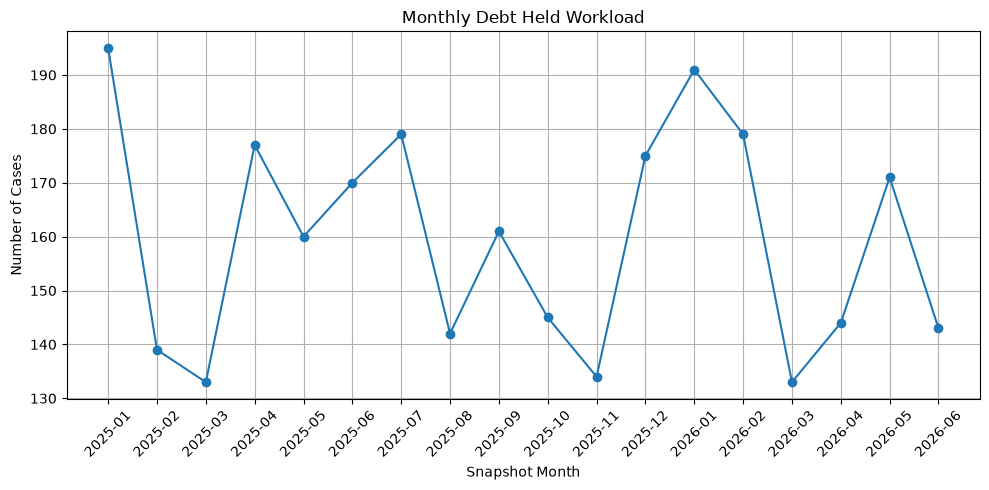

In [9]:
# Plot monthly workload

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_workload["Snapshot Date"].astype(str),
    monthly_workload["Cases"],
    marker="o",
)

plt.title("Monthly Debt Held Workload")
plt.xlabel("Snapshot Month")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

### Findings

Monthly Debt Held workload ranged from **133 to 195 cases** across the 18-month period.

The highest case volumes occurred during **December and January**, reflecting increased seasonal demand and supporting the business rule that these are the busiest months for the Debt Held process.

Outside of the winter period, workload fluctuated between approximately **130 and 180 cases**, demonstrating normal operational variation.

### Business Recommendation

The business should consider allocating additional Debt Held resource during December and January to help manage increased workloads and reduce the likelihood of refund processing delays.

## Refund Type Analysis

Analyse the distribution of missed refund types to identify which scenarios contribute most frequently to the Debt Held workload.

In [10]:
# Analyse refund type distribution

refund_type_summary = (
    debt_held_df["Refund Type"]
    .value_counts()
    .rename_axis("Refund Type")
    .reset_index(name="Cases")
)

refund_type_summary["Percentage"] = (
    refund_type_summary["Cases"]
    / refund_type_summary["Cases"].sum()
    * 100
).round(1)

refund_type_summary

,Refund Type,Cases,Percentage
0,Death of Pet,1559,54.3
1,Cancellation Before Premium Due,735,25.6
2,Cancellation from Renewal (Void),577,20.1


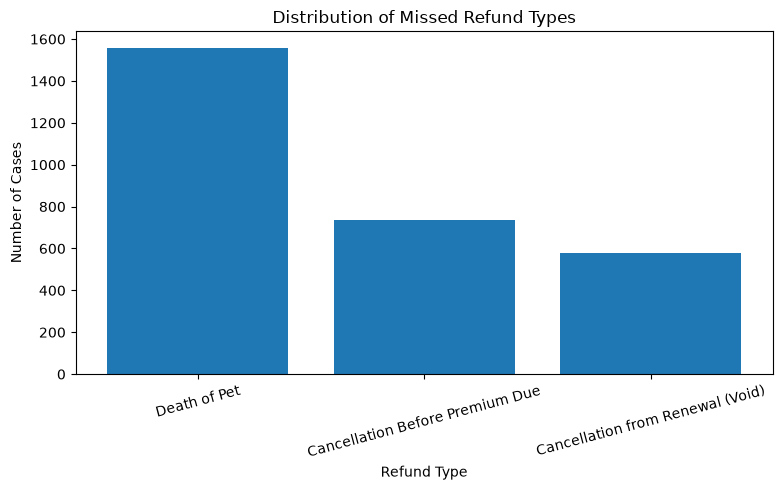

In [11]:
# Plot refund type distribution

plt.figure(figsize=(8, 5))

plt.bar(
    refund_type_summary["Refund Type"],
    refund_type_summary["Cases"],
)

plt.title("Distribution of Missed Refund Types")
plt.xlabel("Refund Type")
plt.ylabel("Number of Cases")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

### Findings

Death of Pet cancellations accounted for **54.3%** of all missed refunds, making them the largest contributor to the Debt Held workload.

Cancellation Before Premium Due represented **25.6%** of cases, while Cancellation from Renewal (Void) accounted for **20.1%**.

The distribution closely reflects the expected operational profile defined within the business rules.

### Business Recommendation

Given that more than half of all missed refunds are associated with Death of Pet cancellations, process reviews and targeted quality assurance should prioritise this refund type. Improvements in this area have the greatest potential to reduce the overall Debt Held workload.

## Root Cause Trend Analysis

Analyse how the causes of missed refunds changed over time.

This helps evaluate the impact of business changes such as training, seasonal workload and the introduction of new starters.

In [12]:
# Calculate root cause percentages by month

root_cause_trends = (
    pd.crosstab(
        debt_held_df["Snapshot Date"].dt.to_period("M"),
        debt_held_df["Root Cause"],
        normalize="index",
    )
    * 100
).round(1)

root_cause_trends

Root Cause,Agent Forgot,Payment Date Misunderstood,Refund Mailbox Delay,Waiting for Information
Snapshot Date,,,,
2025-01,22.1,48.2,17.4,12.3
2025-02,23.7,60.4,5.8,10.1
2025-03,21.8,57.9,11.3,9.0
2025-04,26.0,52.5,10.2,11.3
2025-05,21.2,58.8,13.1,6.9
2025-06,18.8,59.4,9.4,12.4
2025-07,29.1,46.4,9.5,15.1
2025-08,32.4,39.4,10.6,17.6
2025-09,29.2,43.5,8.1,19.3


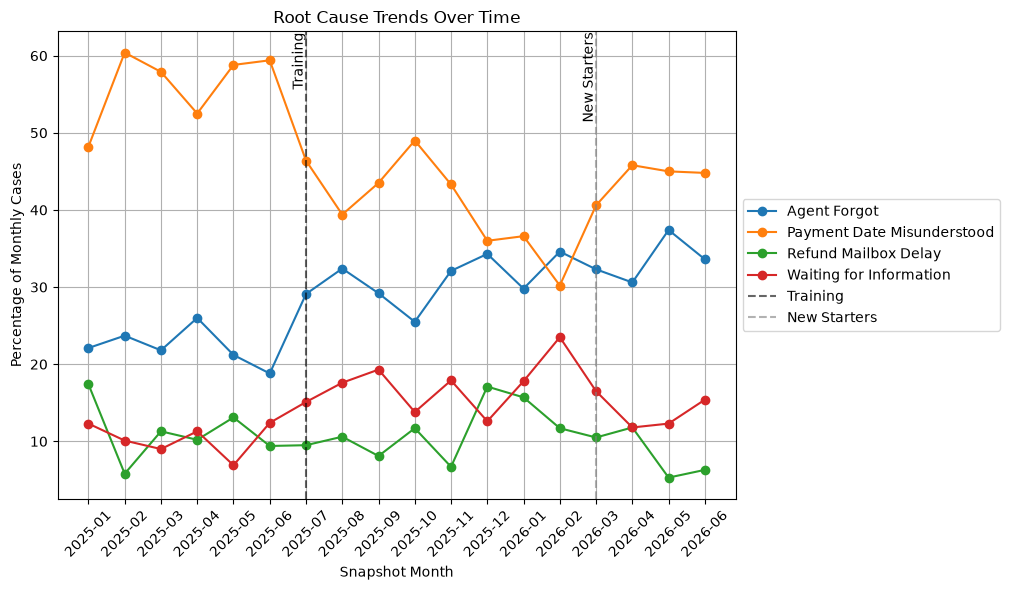

In [16]:
# Plot root cause trends over time

plt.figure(figsize=(12, 6))

for column in root_cause_trends.columns:
    plt.plot(
        root_cause_trends.index.astype(str),
        root_cause_trends[column],
        marker="o",
        label=column,
    )

# Business events
plt.axvline(
    x="2025-07",
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label="Training",
)

plt.axvline(
    x="2026-03",
    color="grey",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label="New Starters",
)

# Event labels
plt.text(
    "2025-07",
    63,
    "Training",
    rotation=90,
    va="top",
    ha="right",
)

plt.text(
    "2026-03",
    63,
    "New Starters",
    rotation=90,
    va="top",
    ha="right",
)

plt.title("Root Cause Trends Over Time")
plt.xlabel("Snapshot Month")
plt.ylabel("Percentage of Monthly Cases")

plt.xticks(rotation=45)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)

plt.grid(True)

plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

### Findings

Payment Date Misunderstood was the most common root cause during the first half of the analysis period, accounting for approximately **50–60%** of monthly missed refunds.

Following the introduction of simulated training in **July 2025**, the proportion of Payment Date Misunderstood cases reduced substantially. Over the same period, Agent Forgot became a larger proportion of missed refunds, suggesting that while the targeted training reduced one type of error, other operational mistakes remained.

Following the simulated arrival of new starters in **March 2026**, Payment Date Misunderstood increased again, although it did not return to the levels observed before training. This indicates that the original training had a lasting positive effect while highlighting the importance of onboarding and refresher training for new colleagues.

Refund Mailbox Delay showed higher proportions during **December and January**, supporting the assumption that increased seasonal workloads can delay refund processing.

Waiting for Information remained relatively stable throughout the 18-month period, suggesting that external dependencies were not significantly affected by operational changes.

### Business Recommendation

The analysis suggests that targeted training can significantly reduce knowledge-based refund errors, particularly those involving payment date calculations.

To maintain these improvements, structured onboarding should be provided to new starters alongside periodic refresher training for existing colleagues.

The increase in Refund Mailbox Delay during December and January also suggests that additional resource or workload planning should be considered during peak seasonal periods to reduce processing delays.

Monitoring root cause trends over time provides an effective way of evaluating whether operational changes are delivering sustained improvements.

## Department Analysis

Analyse which departments generated the most missed refunds.

This helps identify where quality assurance, process reviews and targeted training could have the greatest operational impact.

In [17]:
# Summarise missed refunds by cancelling department

department_summary = (
    debt_held_df["Cancelling Department"]
    .value_counts()
    .rename_axis("Department")
    .reset_index(name="Cases")
)

department_summary["Percentage"] = (
    department_summary["Cases"]
    / department_summary["Cases"].sum()
    * 100
).round(1)

department_summary

,Department,Cases,Percentage
0,Retentions,1205,42.0
1,Customer Service,1023,35.6
2,Claims,453,15.8
3,Complaints,190,6.6


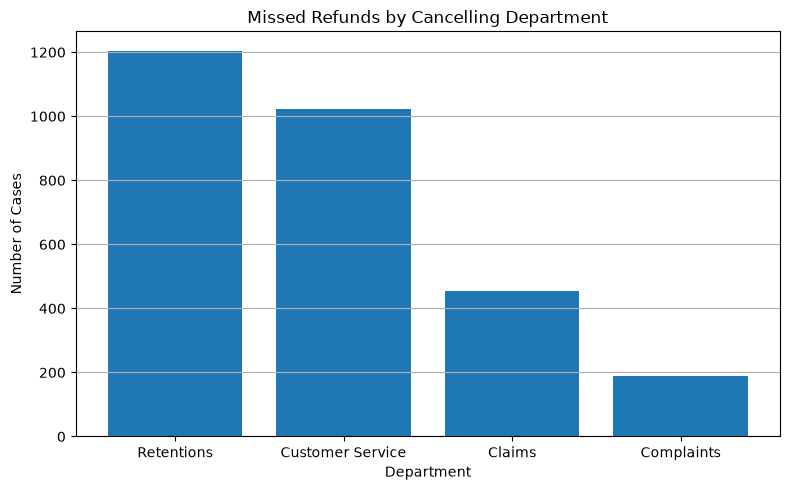

In [18]:
# Plot department distribution

plt.figure(figsize=(8, 5))

plt.bar(
    department_summary["Department"],
    department_summary["Cases"],
)

plt.title("Missed Refunds by Cancelling Department")
plt.xlabel("Department")
plt.ylabel("Number of Cases")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

### Findings

Retentions generated the largest proportion of missed refunds, accounting for **42.0%** of all Debt Held cases.

This result should be interpreted alongside operational workload. Retentions processes the highest volume of policy cancellations and therefore has the greatest number of refund opportunities. A higher number of missed refunds is therefore expected in absolute terms and does not, on its own, indicate poorer performance than other departments.

Customer Service contributed **35.6%** of cases, meaning that together Retentions and Customer Service accounted for almost **78%** of the total missed refund workload.

Claims represented **15.8%** of cases, while Complaints accounted for only **6.6%**, reflecting their comparatively lower cancellation volumes.

### Business Recommendation

Because Retentions and Customer Service generate the largest volumes of cancellations, targeted quality assurance and process improvements within these departments are likely to produce the greatest overall reduction in missed refunds.

Future analysis should compare missed refunds against the total number of cancellations processed by each department to calculate a true missed refund rate. This would enable a fair comparison of departmental performance by accounting for differences in workload.

Although Complaints generates relatively few missed refunds, continued monitoring should ensure that performance remains consistent over time.

## Outstanding Amount Analysis

Analyse the financial value of outstanding refunds to understand the overall financial impact of the Debt Held process.

This analysis identifies where the greatest monetary exposure exists and supports prioritisation of higher-value cases.

In [20]:
monthly_value = (
    debt_held_df
    .groupby(
        debt_held_df["Snapshot Date"].dt.to_period("M")
    )["Outstanding Amount"]
    .sum()
    .reset_index()
)

monthly_value

,Snapshot Date,Outstanding Amount
0,2025-01,11649.74
1,2025-02,7559.31
2,2025-03,7153.59
3,2025-04,10888.28
4,2025-05,8932.56
5,2025-06,9698.16
6,2025-07,9921.97
7,2025-08,7340.79
8,2025-09,8846.14
9,2025-10,7610.74


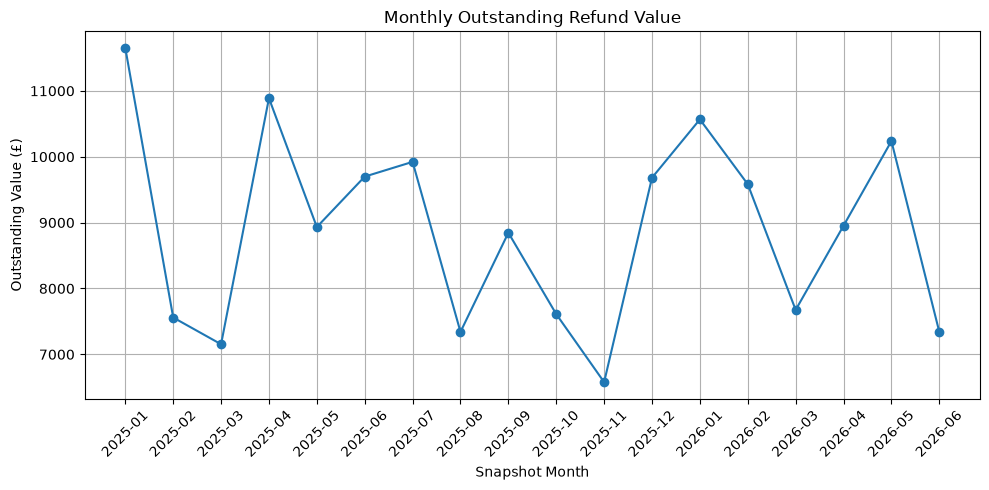

In [21]:
# Plot monthly outstanding value

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_value["Snapshot Date"].astype(str),
    monthly_value["Outstanding Amount"],
    marker="o",
)

plt.title("Monthly Outstanding Refund Value")
plt.xlabel("Snapshot Month")
plt.ylabel("Outstanding Value (£)")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

### Findings

The total outstanding refund value fluctuated throughout the 18-month period, ranging from approximately **£6,600** to **£11,650** per monthly snapshot.

Higher outstanding values generally aligned with months containing larger Debt Held workloads, particularly during January and the winter period.

However, the financial value did not increase in perfect proportion to case volumes, indicating that some months contained a greater concentration of higher-value refunds.

Monitoring both case volume and outstanding value provides a more complete understanding of operational workload and financial exposure.

### Business Recommendation

Operational performance should be monitored using both the number of outstanding cases and their total financial value.

Prioritising higher-value refunds where appropriate may reduce financial exposure while maintaining customer outcomes.

Combining financial and operational metrics provides a more balanced view of Debt Held performance than case volumes alone.

## Financial Impact by Refund Type

Analyse the total and average outstanding refund value for each refund type.

This identifies which business scenarios contribute the greatest financial exposure.

In [23]:
refund_value_summary = (
    debt_held_df
    .groupby("Refund Type")
    .agg(
        Cases=("Refund Type", "count"),
        Total_Value=("Outstanding Amount", "sum"),
        Average_Value=("Outstanding Amount", "mean"),
    )
    .round(2)
    .reset_index()
)

refund_value_summary

,Refund Type,Cases,Total_Value,Average_Value
0,Cancellation Before Premium Due,735,38971.28,53.02
1,Cancellation from Renewal (Void),577,30963.92,53.66
2,Death of Pet,1559,90280.60,57.91


### Findings

Death of Pet refunds represented the greatest overall financial exposure, with a total outstanding value of approximately **£90,281** across the analysis period.

However, this was primarily driven by the higher number of Death of Pet cases rather than significantly larger individual refund values.

The average outstanding value per refund remained relatively consistent across all refund types, ranging from approximately **£53 to £58**.

This suggests that the overall financial impact is influenced more by operational volume than by differences in individual refund amounts.

### Business Recommendation

Reducing the number of missed Death of Pet refunds is likely to deliver the greatest reduction in overall financial exposure due to the high volume of these cases.

Operational improvement initiatives should therefore prioritise the most common refund scenarios, while continuing to monitor average refund values to identify any future changes in financial risk.

# Conclusion

The exploratory analysis identified several recurring operational themes.

Key findings included:

- Payment Date Misunderstood was the leading operational root cause.
- Retentions generated the highest number of missed refund cases.
- Death of Pet refunds represented the largest financial exposure.
- Monthly workloads remained relatively stable with predictable fluctuations.

These findings informed the Power BI dashboard and the process improvement recommendations presented in the following notebook.